### Table from paper on duration vs transmissability
https://www.nature.com/articles/s41586-023-06952-2#Sec10

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/duration_data_from_paper.csv')
df.head()

,binDuration,binAvgRiskScorePerHour,n,probability_of_reported_transmission,lowerCI,upperCI
0,0-0.5,1.1-1.3,592980,0.001891,0.001783,0.002006
1,0-0.5,1.3-1.6,731605,0.001929,0.001829,0.002032
2,0-0.5,1.6-1.8,525992,0.002047,0.001927,0.002173
3,0-0.5,1.8-2.2,691000,0.002213,0.002103,0.002326
4,0-0.5,2.2-3.3,676457,0.002354,0.002239,0.002472


[np.float64(0.0021573673765309595), np.float64(0.006878620143983938), np.float64(0.01663502355345293), np.float64(0.024308541347464574), np.float64(0.040352978957641644), np.float64(0.12288538755708409)]


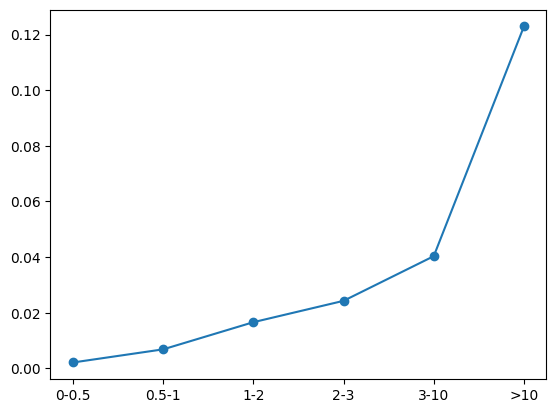

In [10]:
keys = df['binDuration'].unique()
xs, ys = [], []
for key in keys:
    df_tmp = df[df['binDuration'] == key]
    xs.append(key)
    ys.append(sum([df_tmp['probability_of_reported_transmission'].iloc[i] * df_tmp['n'].iloc[i] for i in range(len(df_tmp))]) / sum(df_tmp['n']))
plt.plot(xs, ys, marker='o')
print(ys)

Best-fit beta: 0.0026271307544321965
Best-fit alpha: 0.6939744797796246


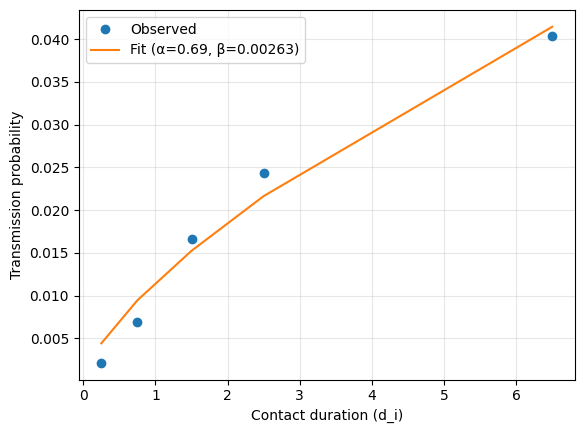

In [ ]:
from scipy.optimize import least_squares

# Model transmission probability
def P_model(beta, gamma, d, alpha):
    beta_i = beta * (d ** alpha)
    lam = beta_i + gamma
    return (beta_i / lam) * (1.0 - np.exp(-lam / gamma))

# Objective for least-squares fitting
def residuals(params, d, P_obs, gamma, fix_beta=False):
    if fix_beta:
        alpha = params[0]
        beta = FIXED_BETA   # define elsewhere if known
    else:
        beta, alpha = params
    P_pred = P_model(beta, gamma, d, alpha)
    return P_pred - P_obs

# Example data (replace with your own)
d_data = np.array([0.25, 0.75, 1.5, 2.5, 6.5])*60  # your 5 duration scales
P_obs  = np.array([0.0021573673765309595, 0.006878620143983938, 0.01663502355345293, 0.024308541347464574, 0.040352978957641644])  # empirical probs
gamma = 1/7  # example: recovery rate per day

# Fit both beta and alpha
x0 = [0.1, 1.0]  # initial guesses for [beta, alpha]
result = least_squares(residuals, x0, args=(d_data, P_obs, gamma))
beta_hat, alpha_hat = result.x

print("Best-fit beta:", beta_hat)
print("Best-fit alpha:", alpha_hat)


P_fit = P_model(beta_hat, gamma, d_data, alpha_hat)

plt.plot(d_data, P_obs, 'o', label='Observed')
plt.plot(d_data, P_fit, '-', label=f'Fit (α={alpha_hat:.2f}, β={beta_hat:.3g})')
plt.xlabel('Contact duration (d_i)')
plt.ylabel('Transmission probability')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Code trying a set of beta choices for duration models before large simulations

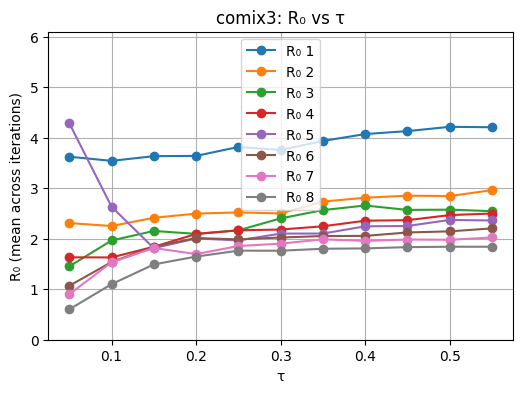

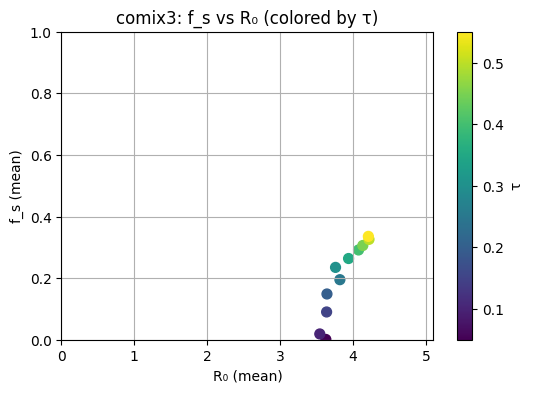

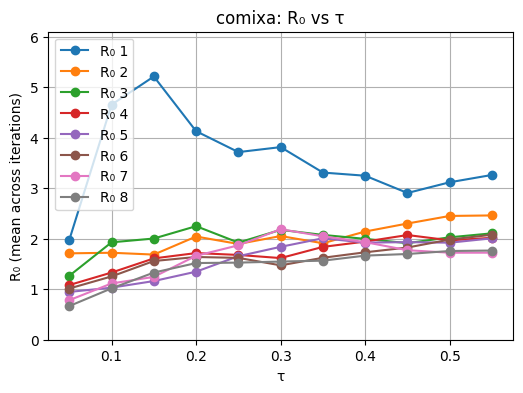

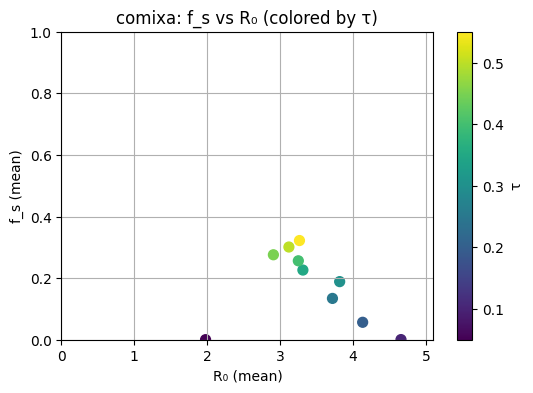

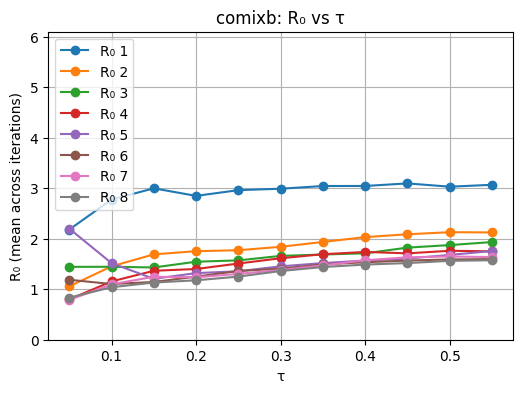

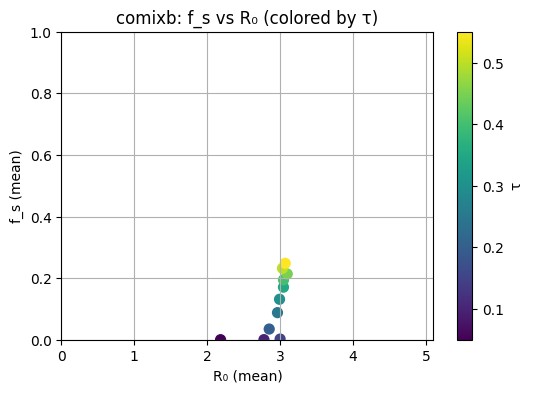

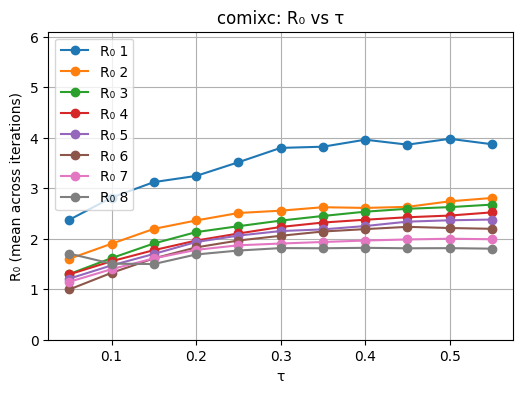

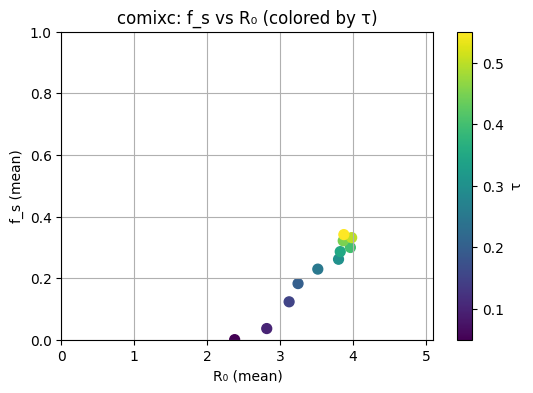

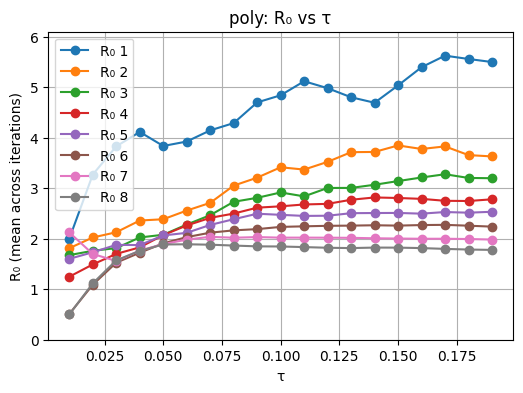

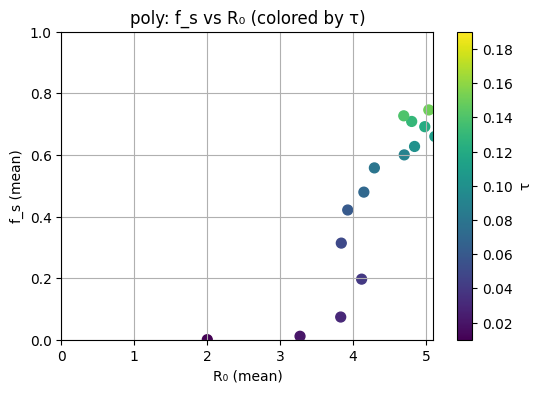

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict

datas = ['comix3','comixa','comixb','comixc','poly']
n=100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

num_network = 20
for data in datas:
    res = {'taus': [], 'fs': [], 'r0': [], 'r02': [], 'r03': [], 'r04': [], 'r05': [], 'r06': [], 'r07': [], 'r08': []}
    for k in range(num_network):
        try:
            with open(f'sims/{data}_{k}_d.json', 'r') as f:
                res_tmp = json.load(f)
            # res['age_dur_sc'] = res_tmp['age_dur_sc']

            for tau, fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row in zip(res_tmp["taus"], res_tmp["fs"], res_tmp["r0"], res_tmp['r02'], res_tmp['r03'], res_tmp['r04'], res_tmp['r05'], res_tmp['r06'], res_tmp['r07'], res_tmp['r08']):
                if tau not in res["taus"]:
                    res["taus"].append(tau)
                    res["fs"].append(fs_row)
                    res["r0"].append(r0_row)
                    res["r02"].append(r02_row)
                    res["r03"].append(r03_row)
                    res["r04"].append(r04_row)
                    res["r05"].append(r05_row)
                    res["r06"].append(r06_row)
                    res["r07"].append(r07_row)
                    res["r08"].append(r08_row)
                else:
                    idx = res["taus"].index(tau)
                    for fs, r0, r02, r03, r04, r05, r06, r07, r08 in zip(fs_row, r0_row, r02_row, r03_row, r04_row, r05_row, r06_row, r07_row, r08_row):
                        res["fs"][idx].append(fs)
                        res["r0"][idx].append(r0)
                        res["r02"][idx].append(r02)
                        res["r03"][idx].append(r03)
                        res["r04"][idx].append(r04)
                        res["r05"][idx].append(r05)
                        res["r06"][idx].append(r06)
                        res["r07"][idx].append(r07)
                        res["r08"][idx].append(r08)
        except:
            a=1
            
    taus = res["taus"]
    r0 = res["r0"]          
    r02 = res["r02"]           
    r03 = res["r03"] 
    r04 = res["r04"]
    r05 = res["r05"]
    r06 = res["r06"]
    r07 = res["r07"]
    r08 = res["r08"]         
    # tmp = res["age_dur_sc"]
    fs = res['fs']
    
    sorted_data = sorted(zip(taus, fs, r0, r02, r03, r04, r05, r06, r07, r08), key=lambda x: x[0])
    taus, fs, r0, r02, r03, r04, r05, r06, r07, r08 = map(list, zip(*sorted_data))

    r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
    r02_mean = [np.mean([b for b in a if b>0]) for a in r02]
    r03_mean = [np.mean([b for b in a if b>0]) for a in r03]
    r04_mean = [np.mean([b for b in a if b>0]) for a in r04]
    r05_mean = [np.mean([b for b in a if b>0]) for a in r05]
    r06_mean = [np.mean([b for b in a if b>0]) for a in r06]
    r07_mean = [np.mean([b for b in a if b>0]) for a in r07]
    r08_mean = [np.mean([b for b in a if b>0]) for a in r08]
    fs_mean = [np.mean([b for b in a if b>0]) for a in fs]
    # tmp_a = {}
    # for i, t in enumerate(taus):
    #     tmp_a[t] = np.array([b for b in tmp[i] if len(b)>0])
    # keys = list(tmp_a.keys())
    # keys.sort()
    # dur_breakdown = []
    # for key in keys:
    #     # print(key, np.mean([[sum(b) for b in a] for a in tmp_a[key]], axis=0).shape)
    #     if len(tmp_a[key]) > 0:
    #         dur_breakdown.append(np.median([[sum(b) for b in a] for a in tmp_a[key]], axis=0))

    # 1) R0 vs taus
    r0_mean = [a if idx in [0,len(r0_mean)] else np.mean(r0_mean[idx-1:idx+2]) for idx, a in enumerate(r0_mean)]
    r02_mean = [a if idx in [0,len(r02_mean)] else np.mean(r02_mean[idx-1:idx+2]) for idx, a in enumerate(r02_mean)]
    r03_mean = [a if idx in [0,len(r03_mean)] else np.mean(r03_mean[idx-1:idx+2]) for idx, a in enumerate(r03_mean)]
    r04_mean = [a if idx in [0,len(r04_mean)] else np.mean(r04_mean[idx-1:idx+2]) for idx, a in enumerate(r04_mean)]
    r05_mean = [a if idx in [0,len(r05_mean)] else np.mean(r05_mean[idx-1:idx+2]) for idx, a in enumerate(r05_mean)]
    r06_mean = [a if idx in [0,len(r06_mean)] else np.mean(r06_mean[idx-1:idx+2]) for idx, a in enumerate(r06_mean)]
    r07_mean = [a if idx in [0,len(r07_mean)] else np.mean(r07_mean[idx-1:idx+2]) for idx, a in enumerate(r07_mean)]
    r08_mean = [a if idx in [0,len(r08_mean)] else np.mean(r08_mean[idx-1:idx+2]) for idx, a in enumerate(r08_mean)]
    plt.figure(figsize=(6,4))
    plt.plot(taus, r0_mean, marker='o', label="R₀ 1")
    plt.plot(taus, r02_mean, marker='o', label="R₀ 2")
    plt.plot(taus, r03_mean, marker='o', label="R₀ 3")
    plt.plot(taus, r04_mean, marker='o', label="R₀ 4")
    plt.plot(taus, r05_mean, marker='o', label="R₀ 5")
    plt.plot(taus, r06_mean, marker='o', label="R₀ 6")
    plt.plot(taus, r07_mean, marker='o', label="R₀ 7")
    plt.plot(taus, r08_mean, marker='o', label="R₀ 8")
    

    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across iterations)")
    plt.title(f"{data}: R₀ vs τ")
    plt.ylim(0, 6.1)
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # new_age = np.zeros((9, 5, len(dur_breakdown)))
    # for i, _ in enumerate(dur_breakdown):
    #     for j in range(9):
    #         for k in range(5):
    #             # print(i, j, k, len(dur_breakdown), len(dur_breakdown[i]), len(dur_breakdown[i][j]))
    #             new_age[j][k][i] = dur_breakdown[i][j][k]
    # for age, tmp in enumerate(new_age):
    #     plt.figure(figsize=(6,4))
    #     for j in range(5):
    #         plt.plot(range(len(tmp[j])), [a/sum([b[idx] for b in tmp]) for idx, a in enumerate(tmp[j])], marker='o', label=f"{duration_labels[j]}")
    #     plt.xlabel(r"$\beta$")
    #     plt.ylabel("mean cases")
    #     plt.title(f"{data}: {bucket_labels[age]}")
    #     plt.ylim(0, 1)
    #     # plt.legend()
    #     plt.grid(True)
    #     plt.show()
    #     plt.close()

    # 3) fs vs R0
    plt.figure(figsize=(6,4))
    plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title(f"{data}: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 5.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

In [31]:
def shape(arr):
    """
    Recursively determine the shape of a nested list (array of arrays).
    Returns a tuple of dimensions.
    """
    if isinstance(arr, (list, tuple)):
        if not arr:  # empty list
            return (0,)
        first_shape = shape(arr[0])
        # Optional: check for irregular shapes
        for sub in arr[1:]:
            if shape(sub) != first_shape:
                raise ValueError("Irregular nested list: inconsistent shapes.")
        return (len(arr),) + first_shape
    else:
        return ()
    
print(shape(res['r0'][0]))


(7, 48)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.optimize import curve_fit
import glob

datas = ['comix3', 'comixa', 'comixb', 'comixc', 'poly']
n = 100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

def logistic(x, L, k, x0):
    """L = upper asymptote, k = slope, x0 = midpoint"""
    return L / (1 + np.exp(-k * (x - x0)))

for data in datas:
    print(f"Processing {data}...")

    # --- Gather all available sim files ---
    files = sorted(glob.glob(f'sims/{data}_*_g.json'))
    if not files:
        print(f"No files found for {data}, skipping.")
        continue

    # --- Initialize aggregation containers ---
    all_taus, all_r0, all_r02, all_r03, all_r04, all_fs = [], [], [], [], [], []
    all_avg_d_network, all_avg_d_input = [], []
    all_tmp = []

    for f in files:
        with open(f, 'r') as infile:
            res = json.load(infile)
        
        taus = np.array(res["taus"])
        all_taus.append(taus)

        all_r0.append(np.array(res["r0"]))
        all_r02.append(np.array(res["r02"]))
        all_r03.append(np.array(res["r03"]))
        all_r04.append(np.array(res["r04"]))
        all_fs.append(np.array(res["fs"]))

        all_tmp.append(res["age_dur_sc"])

        all_avg_d_network.append(np.array(res["avg_d_network"]))
        all_avg_d_input.append(res["avg_d_input"]/n)

    # --- Convert to numpy arrays and average across runs ---
    taus = np.mean(np.vstack(all_taus), axis=0)  # assume same taus in all files

    def mean_over_runs(all_list):
        arr = np.stack(all_list)  # shape: (runs, len(taus), iterations)
        means = [np.mean([b for b in arr[:, i, :].flatten() if b > 0]) for i in range(arr.shape[1])]
        return np.array(means)
    
    r0_mean = mean_over_runs(all_r0)
    r02_mean = mean_over_runs(all_r02)
    r03_mean = mean_over_runs(all_r03)
    r04_mean = mean_over_runs(all_r04)
    fs_mean = mean_over_runs(all_fs)
    print(data)
    print(r0_mean[20], r02_mean[20], r03_mean[20])
    
    avg_d_network = np.mean(np.vstack(all_avg_d_network), axis=0)
    avg_d_input = np.mean(all_avg_d_input)

    # --- R0 vs tau plots ---
    plt.figure(figsize=(6,4))
    plt.scatter(taus, r0_mean, marker='o', label="R₀ 1")
    plt.scatter(taus, r02_mean, marker='o', label="R₀ 2")
    plt.scatter(taus, r03_mean, marker='o', label="R₀ 3")
    plt.scatter(taus, r04_mean, marker='o', label="R₀ 4")

    # Fit logistic curve to each series
    x_fit = np.linspace(min(taus), max(taus), 200)
    for i, r_mean in enumerate([r0_mean, r02_mean, r03_mean, r04_mean], start=1):
        mask = np.isfinite(r_mean)
        try:
            popt, _ = curve_fit(logistic, taus[mask], r_mean[mask], p0=[1, 5, 1])
            plt.plot(x_fit, logistic(x_fit, *popt), label=f"Fit R₀ {i}")
        except RuntimeError:
            print(f"⚠️ Logistic fit failed for {data} R₀ {i}")

    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across runs)")
    plt.title(f"{data}: R₀ vs τ (averaged over {len(files)} runs)")
    plt.ylim(0, 6.1)
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- fs vs R0 ---
    plt.figure(figsize=(6,4))
    plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title(f"{data}: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 4.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # --- avg_d_network vs avg_d_input ---
    plt.figure(figsize=(6,4))
    plt.plot(taus, avg_d_network, marker='^', label="avg_d_network")
    plt.axhline(y=avg_d_input, color='red', linestyle='--', label="avg_d_input")
    plt.xlabel("τ")
    plt.ylabel("Degree")
    plt.title(f"{data}: Network vs Input degree (mean across runs)")
    plt.ylim(0, max(max(avg_d_network), avg_d_input) + .5)
    plt.legend()
    plt.grid(True)
    plt.show()

Processing comix3...


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 56 and the array at index 2 has size 19

### Look at networks small example

make small network example, see whats happening 
compare number of each type of connection in data, gmm and model
make seir possibly?

0.5
1


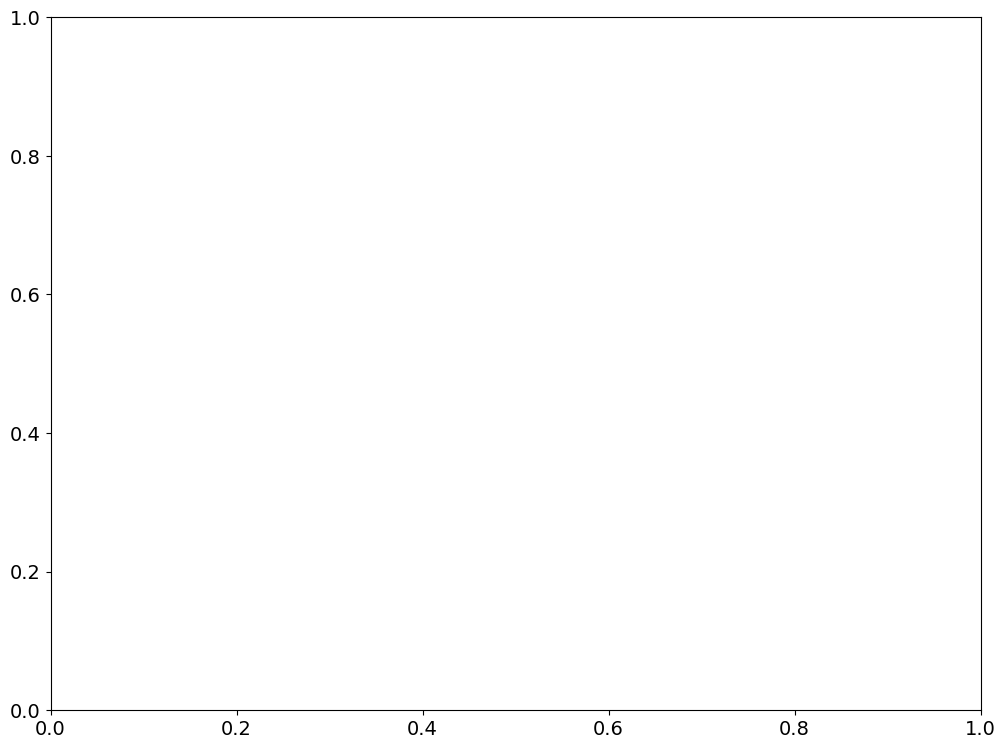

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import nd_python_avon as nd_p 
import numpy as np
import json
import sklearn.mixture
import math
import matplotlib.pyplot as plt

n = 100_000

taus = [0.5,1]


buckets = np.array([5,12,18,30,40,50,60,70])
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n]

per_partition = [a if i == 0 else a-partitions[i-1] for i, a in enumerate(partitions)]

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-1 hour', '1-4 hours', '4+ hours']
datas = ['comix3']


for i, data in enumerate(datas):
    with open(f'data/gmm_opt_comp/optimal_components_{data}_log_smalldur.json', 'r') as f:
        optimal_num_components = json.load(f)
    ##################### read fits ####################################
    with open(f'../input_data/egos/{data}_dur_small.json', 'r') as f:
        egos = json.load(f)
    props = np.genfromtxt(f'../input_data/durations/{data}.csv', delimiter=',')
    
    samples_for_plot = []
    classifier = []
    samples = []
    for l, _ in enumerate(partitions):
        samples_for_plot.append([])
        classifier.append(sklearn.mixture.GaussianMixture(n_components=optimal_num_components[data][l], covariance_type='full'))
        egos_age = [a for a in egos if a['age'] == l]
        ## use log(k+1) instead of k to fit
        X = [[math.log(b+1) for b in a['contacts']] for a in egos_age]
        classifier[l].fit(X)
        ## sample same number of people as the data
        samples_tmp,_ = classifier[l].sample(per_partition[l])
        for sample in samples_tmp:
            samples.append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
            samples_for_plot[-1].append([int(np.round(np.exp(b)-1)) if int(np.round(np.exp(b)-1))>=0 else 0 for b in sample])
    fig1, ax1 = plt.subplots(1,1, figsize=(12,9))
    for tau in taus:
        print(tau)
        res = nd_p.small_dur_gillesp(samples,partitions=partitions,num_dur=3, tau=tau,props=props.tolist(),num_infec=5)
        with open(f'networks/small_{data}_{tau}.json','w') as f:
            json.dump(res, f)

    #     infecs, cur = [], 0
    #     for val in res['i_events']:
    #         cur = cur+1 if val >= 0 else cur-1
    #         infecs.append(cur)
    #     ax1.plot(res['ts'], infecs, label=f'tau={tau}')
    #     ax1.set_xlabel('Time')
    #     ax1.set_ylabel('Number of Infectious Individuals')

    #     fig2, ax2 = plt.subplots(2,3, figsize=(12,9))
    #     for j in range(6):
    #         cur_gen = [idx for idx,b in enumerate(res['generation']) if b==j+1]
    #         contacts_per_duration = np.zeros((len(cur_gen), 5))
    #         sc_per_duration = np.zeros((len(cur_gen), 5))
    #         for idx, person in enumerate(cur_gen):
    #             for contact in res['adjacency_matrix'][person]:
    #                 contacts_per_duration[idx][contact[-1]] += 1
    #                 if res['disease_from'][contact[1]] == person:
    #                     sc_per_duration[idx][contact[-1]] += 1
    #         normal_cpd, normal_scpd = np.copy(contacts_per_duration), np.copy(sc_per_duration)
    #         for idx, person_c, person_sc in enumerate(zip(contacts_per_duration, sc_per_duration)):
    #             if sum(person_c) == 0:
    #                 contacts_per_duration[idx] / sum(person_c)
    #             if sum(person_sc) == 0:
    #                 sc_per_duration[idx] / sum(person_sc)
    #         x = np.arange(len(cur_gen))
    #         colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))
    #         bottom = np.zeros(len(cur_gen))
    #         for idx in range(5):
    #             # print(normal_cpd.shape, bottom.shape)
    #             ax2[j//3][j%3].bar(x, normal_cpd[:, idx], bottom=bottom, color=colors[idx], edgecolor="black")
    #             bottom += normal_cpd[:, idx]
    #         sums = contacts_per_duration.sum(axis=1)
    #         for idx, s in enumerate(sums):
    #             ax2[j//3][j%3].text(idx, s + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
                
    #         for idx in range(5):
    #             ax2[j//3][j%3].bar(x, bottom, bottom=normal_scpd[:,idx], color=colors[idx], edgecolor="black")
    #             bottom -= normal_scpd[:, idx]
    #         sums = sc_per_duration.sum(axis=1)
    #         for idx, s in enumerate(sums):
    #             ax2[j//3][j%3].text(idx, s + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=9)
    #         ax2[j//3][j%3].set_ylabel("Contact durations")
    #         ax2[j//3][j%3].set_xlabel("Index")
    #         ax2[j//3][j%3].set_xticklabels(cur_gen)
    #         ax2[j//3][j%3].set_title(f"Generation {j+1}")
    #         ax2[j//3][j%3].set_ylim(0, 1.1)
    #         # ax2[j//3][j%3].set_xticks(x)

    # ax1.legend()
    # plt.show()

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}


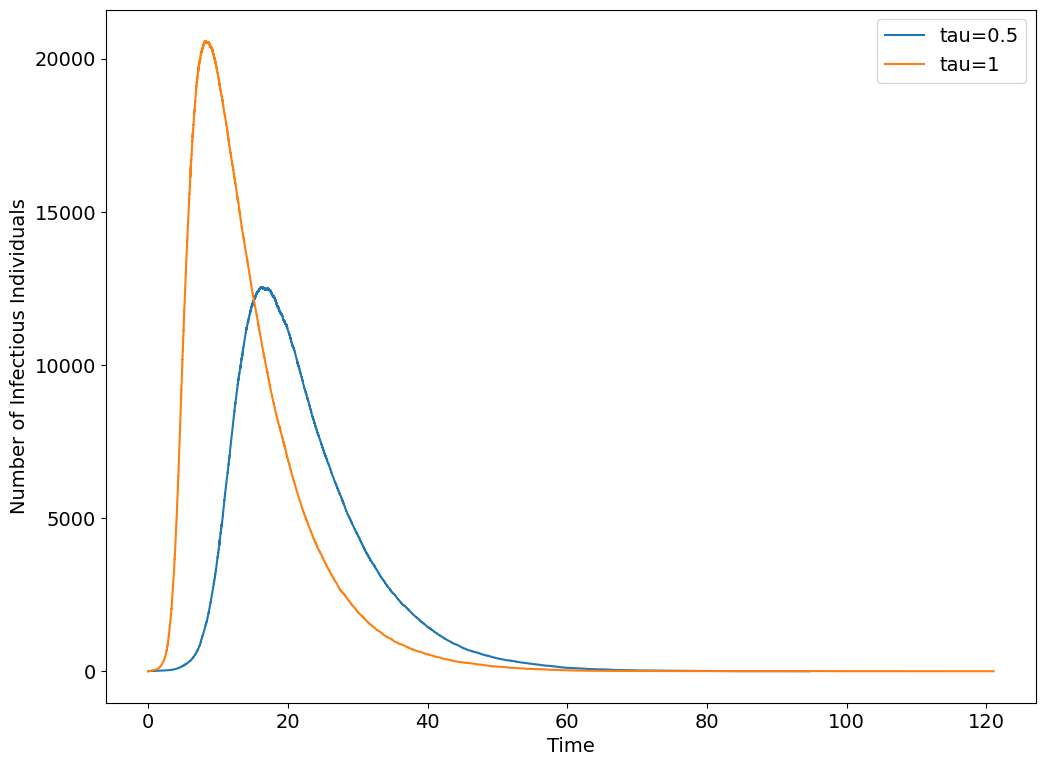

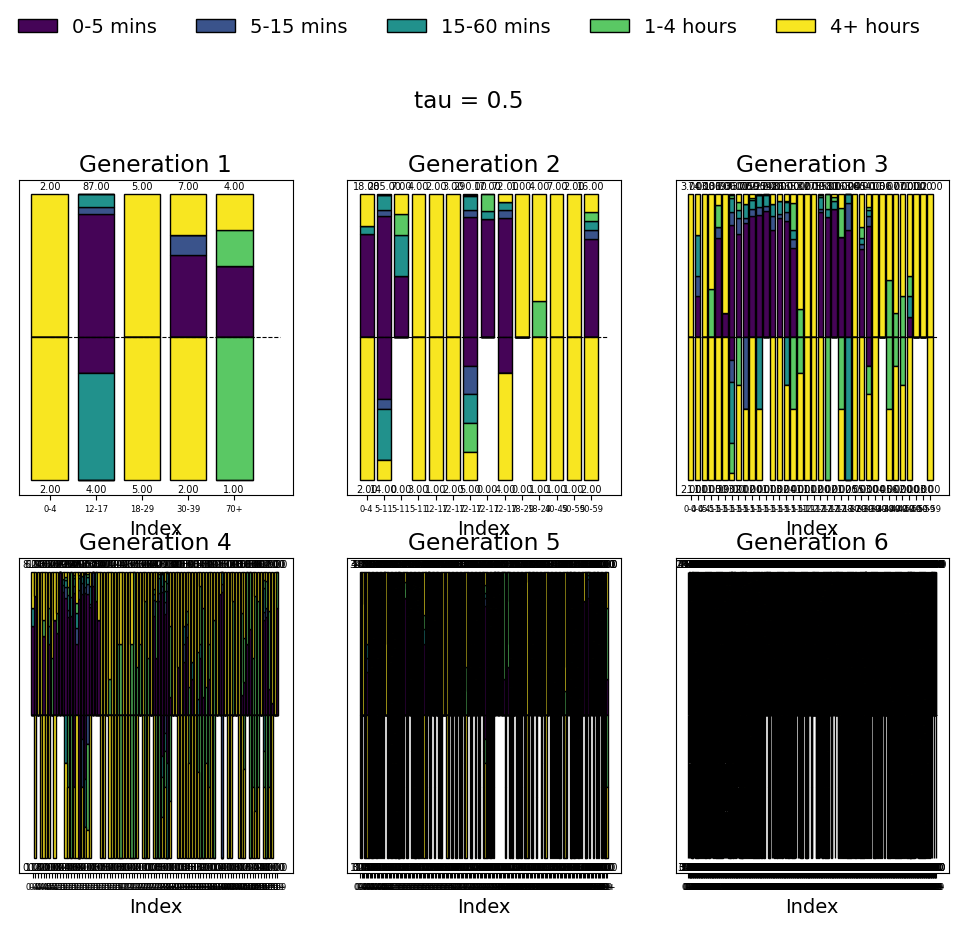

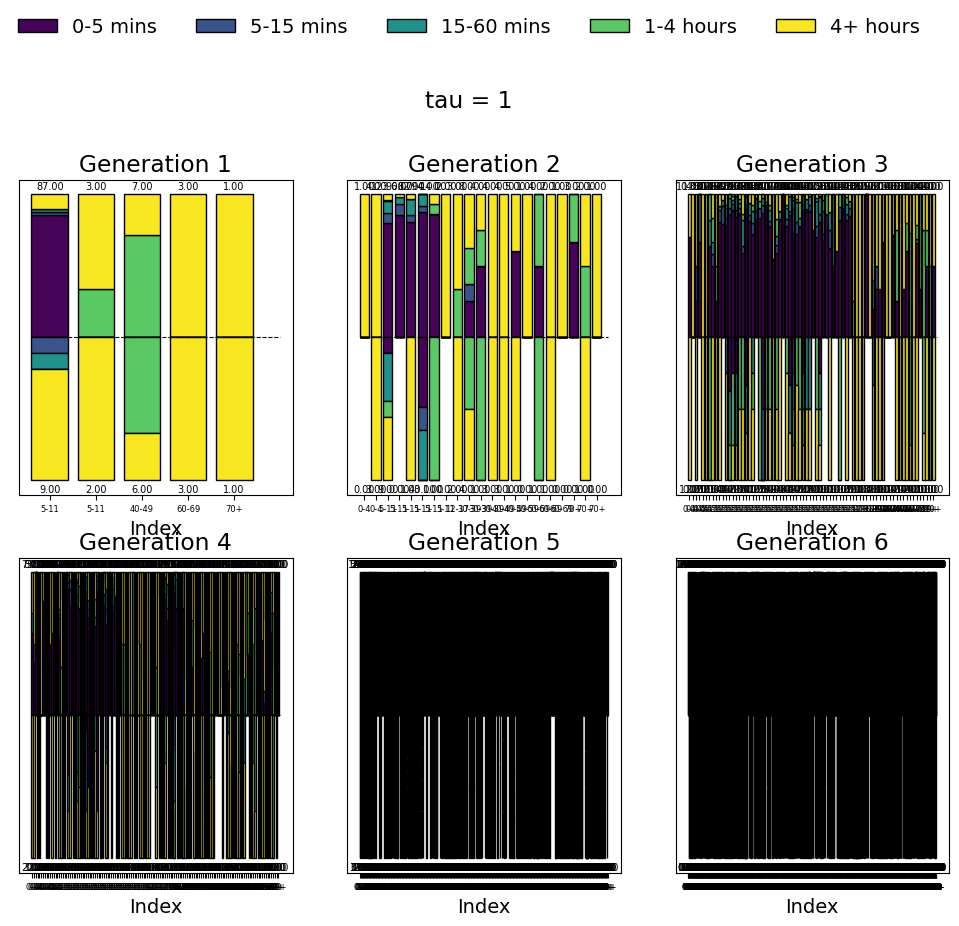

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import nd_python_avon as nd_p 
import numpy as np
import json
import sklearn.mixture
import math
import matplotlib.pyplot as plt

n = 100_000

taus = [.5,1]


buckets = np.array([5,12,18,30,40,50,60,70])
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n]

per_partition = [a if i == 0 else a-partitions[i-1] for i, a in enumerate(partitions)]

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']
dur_label = ['5','15', '60', '2', '4']
datas = ['comix3']


for i, data in enumerate(datas):
    with open(f'../input_data/egos/{data}_dur_small.json', 'r') as f:
        egos = json.load(f)
    fig1, ax1 = plt.subplots(1,1, figsize=(12,9))
    for tau in taus:
        # res = nd_p.small_dur_gillesp(samples,partitions=partitions,num_dur=3, tau=tau,props=props.tolist())
        # with open(f'networks/small_{data}_{tau}.json','w') as f:
        #     json.dump(res, f)
        with open(f'networks/small_{data}_{tau}.json','r') as f:
            res = json.load(f)
        infecs, cur = [], 0
        for val in res['i_events']:
            cur = cur+1 if val >= 0 else cur-1
            infecs.append(cur)
        ax1.plot(res['ts'], infecs, label=f'tau={tau}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Number of Infectious Individuals')

        fig2, ax2 = plt.subplots(2,3, figsize=(12,9))
        print(set(res['generation']))
        for j in range(6):
            cur_gen = [idx for idx,b in enumerate(res['generation']) if b==j+1]
            contacts_per_duration = np.zeros((len(cur_gen), 5))
            sc_per_duration = np.zeros((len(cur_gen), 5))
            for idx, person in enumerate(cur_gen):
                for contact in res['adjacency_matrix'][person]:
                    contacts_per_duration[idx][contact[-1]] += 1
                    if res['disease_from'][contact[1]] == person:
                        sc_per_duration[idx][contact[-1]] += 1
            normal_cpd, normal_scpd = np.zeros((len(cur_gen), 5)), np.zeros((len(cur_gen), 5))
            for idx, _ in enumerate(normal_cpd):
                if sum(contacts_per_duration[idx]) != 0:
                    normal_cpd[idx] = contacts_per_duration[idx] / sum(contacts_per_duration[idx])
                if sum(sc_per_duration[idx]) != 0:
                    normal_scpd[idx] = sc_per_duration[idx] / sum(sc_per_duration[idx])
            x = np.arange(len(cur_gen))
            colors = plt.cm.viridis(np.linspace(0.01, .99, 5))
            bottom = np.zeros(len(cur_gen))
            bars = []
            for idx in range(5):
                # print(len(normal_cpd), len(x))
                bar = ax2[j//3][j%3].bar(x, normal_cpd[:, idx], bottom=bottom, color=colors[idx], edgecolor="black")
                bottom += normal_cpd[:, idx]
                bars.append(bar)
            sums = contacts_per_duration.sum(axis=1)
            for idx, s in enumerate(sums):
                ax2[j//3][j%3].text(idx, 1 + 0.02, f"{s:.2f}", ha="center", va="bottom", fontsize=7)
            bottom = np.zeros(len(cur_gen))
            for idx in range(5):
                bottom -= normal_scpd[:, idx]
                ax2[j//3][j%3].bar(x, normal_scpd[:,idx], bottom=bottom, color=colors[idx], edgecolor="black", label=f'{duration_labels[idx]}' if j==0 else '')
            sums = sc_per_duration.sum(axis=1)
            for idx, s in enumerate(sums):
                ax2[j//3][j%3].text(idx, -1 - 0.1, f"{s:.2f}", ha="center", va="bottom", fontsize=7)
            ax2[j//3][j%3].plot([0,len(cur_gen)], [0,0], color='black', linestyle='--', linewidth=0.8)
            ax2[j//3][j%3].set_xlabel("Index")
            ax2[j//3][j%3].set_yticks([])
            ax2[j//3][j%3].set_xticks(x)
            ax2[j//3][j%3].set_xticklabels([bucket_labels[res['ages'][a]] for a in cur_gen], fontsize=6)
            ax2[j//3][j%3].set_title(f"Generation {j+1}")
            ax2[j//3][j%3].set_ylim(-1.1, 1.1)

        fig2.suptitle(f'tau = {tau}')
        fig2.legend(
            handles=[b[0] for b in bars if len(b)>0],  # first rectangle from each stack
            labels=duration_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.08),  # position legend above the figure
            ncol=5,
            frameon=False
        )
    ax1.legend()
    plt.show()

In [4]:
infec_times = np.zeros(len(res['degrees']))
for t,i in [(i,a) for i, a in enumerate(res['r_events']) if a >= 0]:
    infec_times[i] += res['ts'][t]
for t,i in [(i,a) for i, a in enumerate(res['i_events']) if a >= 0]:
    infec_times[i] -= res['ts'][t]
    
print(np.mean([a for a in infec_times if a > 0]))
print(1/7)

7.018430629420311
0.14285714285714285


In [5]:
print(res['i_events'][:20])
print(res['r_events'][:20])
print(res['ts'][0:20])

[6347, 10005, 61942, 78891, 89790, 7122, 89534, 37912, 91924, 77744, 2190, -1, 95671, 50574, 76944, 4249, 12781, 7557, 48677, 9142]
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 7122, -1, -1, -1, -1, -1, -1, -1, -1]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.06293772205762291, 0.0872869584980892, 0.09883227870466917, 0.12507428312738114, 0.1707910754154364, 0.2791048756134453, 0.2960177246554053, 0.31824970895932314, 0.3769572285844806, 0.38123867806283007, 0.39094378186270284, 0.39352940077371834, 0.40303755426712395, 0.4077846403588703, 0.41902668198916987]


In [ ]:
for gen in range(1,6):
    for i, sc in [(idx,s) for idx, s in enumerate(res['degrees'])]
    